In [13]:
#do not run this section
'''
import numpy as np
from scipy.signal import firwin, freqz
import matplotlib.pyplot as plt

# Filter requirements
fs = 50000  # Sample rate, Hz
band = [5000, 10000]  # Desired band-pass range, Hz
trans_width = 100  # Width of transition from pass band to stop band, Hz
numtaps = 101  # Size of the FIR filter

# Compute the filter coefficients using the firwin function
taps = firwin(numtaps, band, window='hann', pass_zero=False, fs=fs)

# Compute the frequency response of the filter
w, h = freqz(taps, 1, worN=2000)

# Plot the frequency response
fig, ax1 = plt.subplots()
ax1.set_title('Digital filter frequency response')
ax1.plot(0.5*fs*w/np.pi, 20*np.log10(np.abs(h)), 'b')
ax1.set_ylabel('Amplitude [dB]', color='b')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylim([-100, 10])
ax1.set_xlim([0, 0.5*fs])
ax1.grid()

plt.show()


#base code from https://github.com/arif-du/Digital-Signal-Processing-with-Python/blob/main/16_FIR_filter.ipynb
'''

"\nimport numpy as np\nfrom scipy.signal import firwin, freqz\nimport matplotlib.pyplot as plt\n\n# Filter requirements\nfs = 50000  # Sample rate, Hz\nband = [5000, 10000]  # Desired band-pass range, Hz\ntrans_width = 100  # Width of transition from pass band to stop band, Hz\nnumtaps = 101  # Size of the FIR filter\n\n# Compute the filter coefficients using the firwin function\ntaps = firwin(numtaps, band, window='hann', pass_zero=False, fs=fs)\n\n# Compute the frequency response of the filter\nw, h = freqz(taps, 1, worN=2000)\n\n# Plot the frequency response\nfig, ax1 = plt.subplots()\nax1.set_title('Digital filter frequency response')\nax1.plot(0.5*fs*w/np.pi, 20*np.log10(np.abs(h)), 'b')\nax1.set_ylabel('Amplitude [dB]', color='b')\nax1.set_xlabel('Frequency [Hz]')\nax1.set_ylim([-100, 10])\nax1.set_xlim([0, 0.5*fs])\nax1.grid()\n\nplt.show()\n\n\n#base code from https://github.com/arif-du/Digital-Signal-Processing-with-Python/blob/main/16_FIR_filter.ipynb\n"

Sample rate: 22050 Hz
Number of samples: 105507
Duration: 4.78 seconds


/var/folders/wn/3w4qxxnj6ml45c3mrvwn97qc0000gn/T/ipykernel_29065/2637231603.py:13: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, signal = wavfile.read(wav_path)


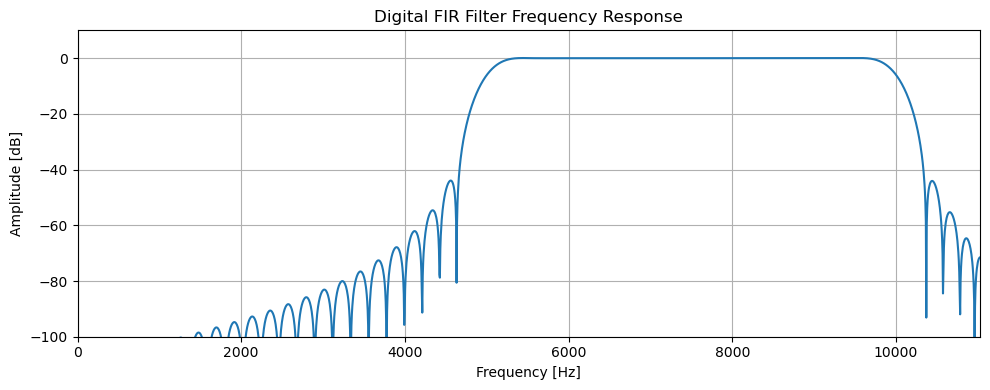

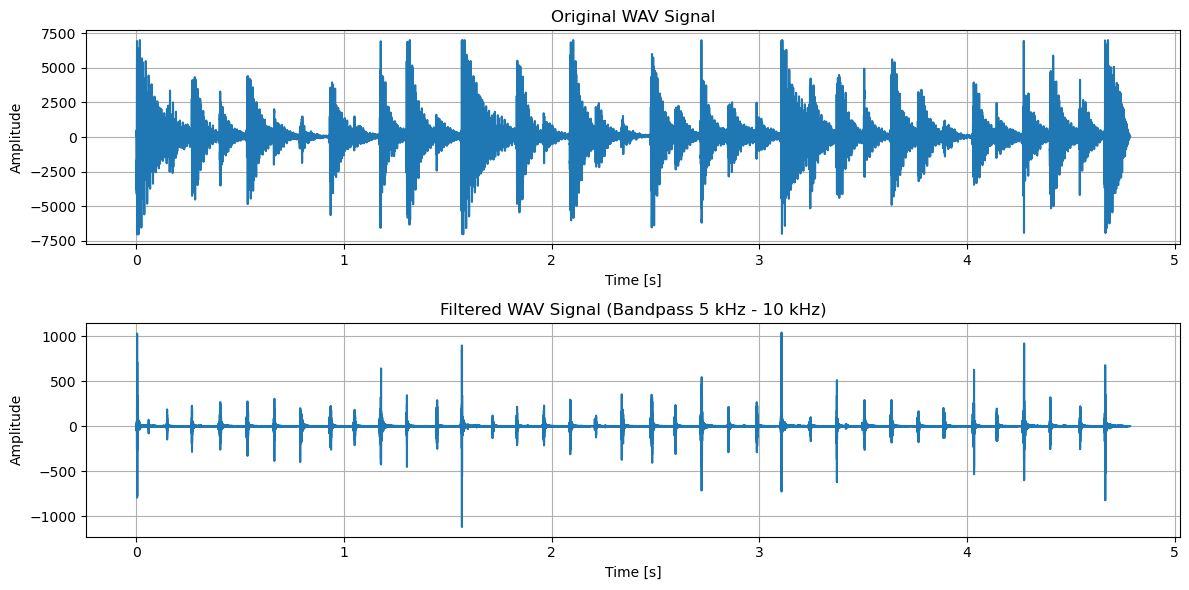

[-0.00000000e+00  2.19219244e-06 -8.59558895e-06  1.05174017e-04
 -1.28786068e-04 -7.15168558e-05 -3.53383005e-05  3.49762812e-04
  2.08026164e-04 -9.14954316e-04  2.62489423e-04 -8.48913405e-05
  1.88934614e-03 -2.19767179e-03  5.04247525e-05 -6.13780214e-04
  3.15653341e-03 -7.96711228e-04 -3.07742896e-03  5.77016529e-04
  1.21171128e-03  5.25922783e-03 -8.12913669e-03  1.56641951e-03
 -2.04770546e-03  1.09788459e-02 -7.18713772e-03 -4.32575321e-03
 -6.08329647e-04  8.02694122e-03  6.73474218e-03 -1.83726696e-02
  4.59435367e-03 -2.46321034e-03  2.62785181e-02 -2.57174866e-02
 -1.45075874e-03 -5.93164126e-03  3.07041024e-02 -2.73570792e-03
 -3.49240221e-02  7.73206617e-03  7.43839165e-03  6.11244862e-02
 -8.96798871e-02  1.54558832e-02 -2.88722037e-02  1.76038068e-01
 -1.33077915e-01 -2.23055296e-01  4.53531532e-01 -2.23055296e-01
 -1.33077915e-01  1.76038068e-01 -2.88722037e-02  1.54558832e-02
 -8.96798871e-02  6.11244862e-02  7.43839165e-03  7.73206617e-03
 -3.49240221e-02 -2.73570

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz, lfilter
from scipy.io import wavfile

#modified base code from https://github.com/arif-du/Digital-Signal-Processing-with-Python/blob/main/16_FIR_filter.ipynb
def FIR_python(wav_file, low_freq, high_freq):
    #read .wav
    wav_path = wav_file
    
    fs, signal = wavfile.read(wav_path)
    
    # If multi-channel convert to mono by averaging channels
    if len(signal.shape) > 1:
        signal = signal.mean(axis=1)
    
    # Normalize if integer type
    if np.issubdtype(signal.dtype, np.integer):
        signal = signal.astype(np.float32) / np.iinfo(signal.dtype).max
    else:
        signal = signal.astype(np.float32)
    
    print(f"Sample rate: {fs} Hz")
    print(f"Number of samples: {len(signal)}")
    print(f"Duration: {len(signal)/fs:.2f} seconds")
    
    
    # Filter requirements
    band = [low_freq, high_freq]   # Desired band-pass range, Hz
    numtaps = 101          # FIR filter length, may move this into the function
    
    #Compute FIR coefficients using Hanning window
    taps = firwin(numtaps, band, window='hann', pass_zero=False, fs=fs)
    
    #Frequency response
    w, h = freqz(taps, 1, worN=2000, fs=fs)
    
    plt.figure(figsize=(10, 4))
    plt.title("Digital FIR Filter Frequency Response")
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12))
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Amplitude [dB]")
    plt.ylim([-100, 10])
    plt.xlim([0, fs / 2])
    plt.grid()
    plt.tight_layout()
    plt.show()
    
    #Filter WAV signal
    filtered_signal = lfilter(taps, 1, signal)
    

    #Time-domain plots
    time = np.arange(len(signal)) / fs
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(time, signal)
    plt.title("Original WAV Signal")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.grid()
    
    plt.subplot(2, 1, 2)
    plt.plot(time, filtered_signal)
    plt.title("Filtered WAV Signal (Bandpass 5 kHz - 10 kHz)")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.grid()
    
    plt.tight_layout()
    plt.show()
    print(taps) 



FIR_python("drmapan.wav", 5000, 10000) #function call

